In [1]:
# general
import numpy as np
from numpy.random import PCG64, SeedSequence
import pandas as pd
import verde as vd
import harmonica as hm
from scipy import interpolate
import xarray as xr
import cmocean
from cmcrameri import cm
import geopandas as gpd
from skgstat import models
import gstatsim as gsm

# plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import animation

# io
from tqdm.auto import tqdm
import os
from pathlib import Path
import time

import sys
sys.path.append('../../src')

import preprocessing
import block_update
import bouguer
import diagnostics
import rfgen
import utilities
import postprocessing
import gstatsim_custom
import gaussnewton

import importlib
importlib.reload(preprocessing)
importlib.reload(block_update)
importlib.reload(bouguer)
importlib.reload(diagnostics)
importlib.reload(rfgen)
importlib.reload(utilities)
importlib.reload(postprocessing)
importlib.reload(gstatsim_custom)
importlib.reload(gaussnewton)

from preprocessing import *
from block_update import *
from bouguer import *
from diagnostics import *
from rfgen import *
from utilities import *
from postprocessing import *
from gstatsim_custom import *
from gaussnewton import *

In [2]:
bm_path = Path('D:/bedmachine/BedMachineAntarctica-v3.nc')
antgg_path = Path('D:/AntGG2021_allfiles/AntGG2021_Gravity_disturbance_at-surface.nc')

# MOA: https://nsidc.org/data/nsidc-0730/versions/1
moa_base = Path('D:/nsidc0730_MEASURES_MOA2014_v01')

# moa coast and grounding line
moa_coast = gpd.read_file(moa_base/'coastlines/moa2014_coastline_v01.shp')
moa_gl = gpd.read_file(moa_base/'coastlines/moa2014_grounding_line_v01.shp')
moa_island = gpd.read_file(moa_base/'coastlines/moa2014_islands_v01.shp')

glkm = moa_gl.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')
coastkm = moa_coast.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')
islandkm = moa_island.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')

In [3]:
ds = xr.load_dataset(Path('maudeast.nc'))
ds

<xarray.Dataset> Size: 1MB
Dimensions:       (y: 80, x: 200)
Coordinates:
  * x             (x) float64 2kB -1.475e+05 -1.425e+05 ... 8.425e+05 8.475e+05
  * y             (y) float64 640B 1.902e+06 1.908e+06 ... 2.292e+06 2.298e+06
Data variables: (12/13)
    bed           (y, x) float32 64kB 405.0 906.9 ... -4.054e+03 -4.057e+03
    surface       (y, x) float32 64kB 1.727e+03 1.726e+03 ... 15.0 15.0
    thickness     (y, x) float32 64kB 1.322e+03 818.7 156.4 ... 0.0 0.0 0.0
    mask          (y, x) float64 128kB 2.0 2.0 2.0 2.0 2.0 ... 0.0 0.0 0.0 0.0
    geoid         (y, x) float64 128kB 12.0 12.0 12.0 12.0 ... 15.0 15.0 15.0
    source        (y, x) float64 128kB 5.0 5.0 3.0 5.0 5.0 ... 1.0 1.0 1.0 1.0
    ...            ...
    errbed        (y, x) float32 64kB 32.0 48.0 34.0 80.0 ... nan 10.0 10.0 10.0
    inv_msk       (y, x) bool 16kB False False False False ... False False False
    inv_pad       (y, x) bool 16kB False False False False ... False False False
    grav_surface  (y, x) float64 128kB 6.035 29.57 52.59 ... -11.83 -10.53
    grav_1500     (y, x) float64 128kB 0.7188 30.1 57.56 ... -11.42 -10.17
    stdev         (y, x) float64 128kB 3.433 3.508 3.677 ... 8.533 8.535 8.537
Attributes:
    res:      5000

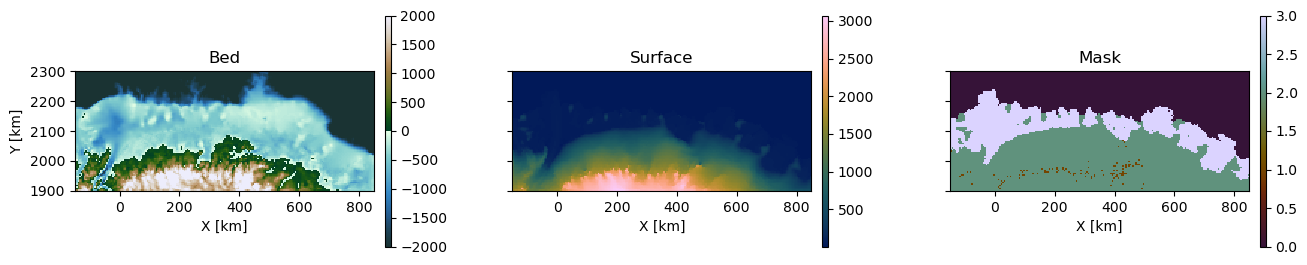

In [4]:
bedmachine_plots(ds, figsize=(16,3))

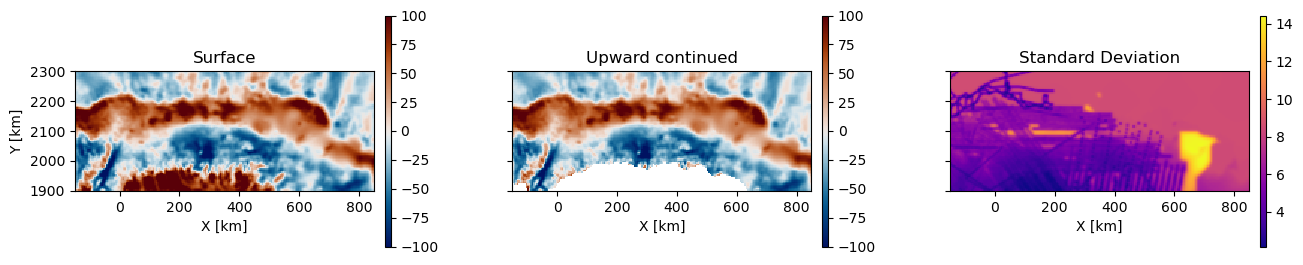

In [5]:
plot_gravity(ds, ds.grav_surface.values, ds.grav_1500.values, ds.stdev.values, 1500, (16,3), 100)

In [6]:
grav = pd.read_csv('maudeast_grav.csv')

xx, yy = np.meshgrid(ds.x.values, ds.y.values)
grav_mask = ds.surface.values < 1500

print(f'{grav.shape[0]} points')
grav.head()

14147 points


,x,y,height,faa,inv_msk,inv_pad,stdev
0,-97500.0,1902500.0,1500,85.450746,False,False,3.761158
1,-92500.0,1902500.0,1500,-11.181967,False,False,4.038851
2,-87500.0,1902500.0,1500,-50.787838,False,False,3.968420
3,-82500.0,1902500.0,1500,-65.749377,False,False,3.989317
4,-77500.0,1902500.0,1500,-73.857366,False,False,3.721502


In [7]:
%%time

g_z = bm_terrain_effect(ds, grav)

CPU times: total: 2min 57s
Wall time: 12.8 s


In [8]:
g_z_grid = xy_into_grid(ds.x.values, ds.y.values, (grav.x.values, grav.y.values), g_z)
gdist_masked = np.where(grav_mask, ds.grav_1500.values, np.nan)
boug_grid = gdist_masked-g_z_grid

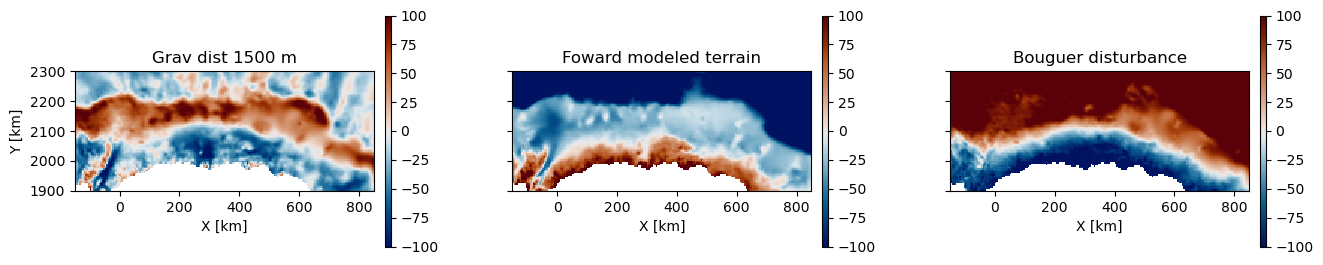

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(16,3), sharey=True)
ax = axs[0]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, gdist_masked, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Grav dist 1500 m')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, g_z_grid, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Foward modeled terrain')
ax.set_xlabel('X [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, boug_grid, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Bouguer disturbance')
ax.set_xlabel('X [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

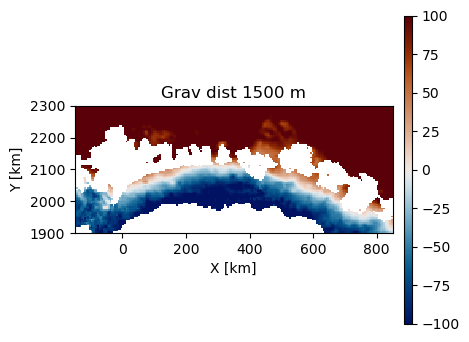

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5,4), sharey=True)
im = ax.pcolormesh(ds.x/1000, ds.y/1000, np.where(ds.inv_msk, np.nan, boug_grid), cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Grav dist 1500 m')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

In [11]:
boug_dist = boug_grid[grav_mask]

trend = rbf_trend(ds, grav, boug_dist, smoothing=1e10, full_grid=True)
residual_grid = boug_grid-trend

trend.shape

(80, 200)

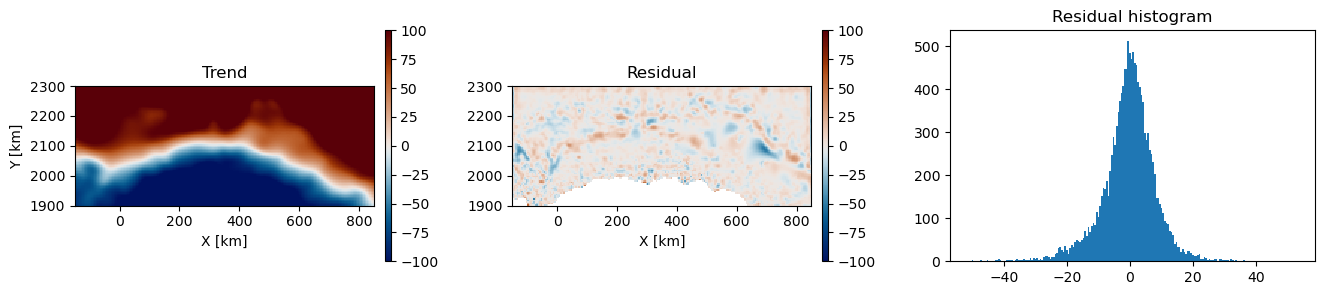

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(16,3), sharey=False)
ax = axs[0]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, trend, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Trend')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, residual_grid, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Residual')
ax.set_xlabel('X [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
ax.hist(residual_grid.flatten(), bins=200)
ax.set_title('Residual histogram')

plt.show()

In [13]:
cond_msk = (np.abs(residual_grid)<25) & (ds.inv_msk==False)
res_grid_mod = np.where(cond_msk, residual_grid, np.nan)

In [14]:
vgrams, experimental, bins = utilities.variograms(xx, yy, res_grid_mod, maxlag=30e3, n_lags=20)

In [15]:
# evaluate models
xi =np.linspace(0, bins[-1], 100) 

y_exp = models.exponential(xi, *vgrams['exponential'])
y_gauss = models.gaussian(xi, *vgrams['gaussian'])
y_sph = models.spherical(xi, *vgrams['spherical'])
y_matern = models.matern(xi, *vgrams['matern'])

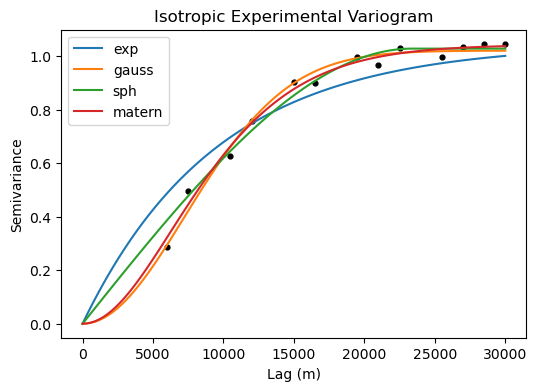

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(bins, experimental, s=12, c='k')
plt.plot(xi, y_exp, label='exp')
plt.plot(xi, y_gauss, label='gauss')
plt.plot(xi, y_sph, label='sph')
plt.plot(xi, y_matern, label='matern')
plt.title('Isotropic Experimental Variogram')
plt.xlabel('Lag (m)'); plt.ylabel('Semivariance')
plt.legend()
plt.show()

In [17]:
# random number generator
rng = np.random.default_rng(seed=0)

k = 48
rad = 500_000

parameters = vgrams['matern']

vario = {
    'azimuth' : 0,
    'nugget' : parameters[-1],
    'major_range' : parameters[0],
    'minor_range' : parameters[0],
    'sill' : parameters[1],
    'vtype' : 'matern',
    's' : parameters[2]
}

# vario = {
#     'azimuth' : 0,
#     'nugget' : parameters[-1],
#     'major_range' : parameters[0],
#     'minor_range' : parameters[0],
#     'sill' : parameters[1],
#     'vtype' : 'spherical'
# }

In [18]:
density_dict = {
    'ice' : 917,
    'water' : 1027,
    'rock' : 2670
}
min_bound, boug_max_grid = bouguer_lower_bound(ds, grav, trend, density_dict)

bounds = (min_bound, 100)

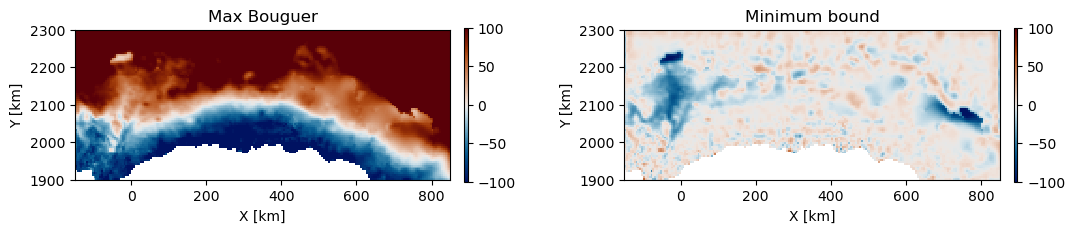

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(13,2))
ax = axs[0]
im = ax.pcolormesh(ds.x.values/1000, ds.y.values/1000, boug_max_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Max Bouguer')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x.values/1000, ds.y.values/1000, min_bound, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Minimum bound')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

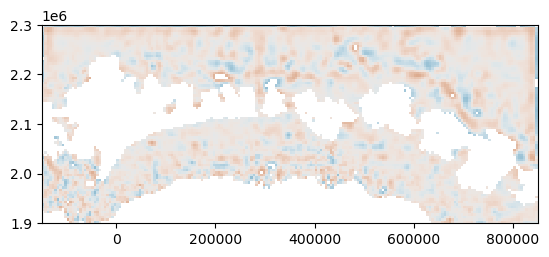

In [20]:
plt.pcolormesh(xx, yy, res_grid_mod, vmin=-100, vmax=100, cmap=cm.vik)
plt.axis('scaled')
plt.show()

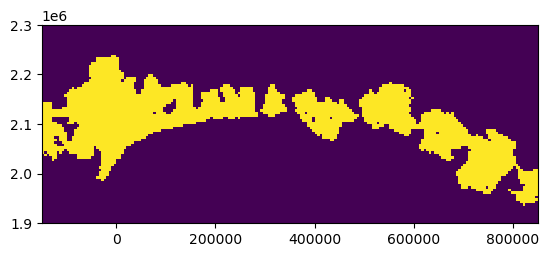

In [21]:
plt.pcolormesh(xx, yy, ds.inv_msk.values)
#plt.plot(xx[56,0], yy[56,0], 'ko')
plt.axis('scaled')
plt.show()

In [22]:
sim1 = interpolate.sgs(xx, yy, res_grid_mod, vario, rad, k, sim_mask=ds.inv_msk.values, seed=rng, bounds=bounds)

  0%|          | 0/3305 [00:00<?, ?it/s]

In [23]:
sim2 = interpolate.sgs(xx, yy, res_grid_mod, vario, rad, k, sim_mask=ds.inv_msk.values, seed=rng, bounds=bounds)

  0%|          | 0/3305 [00:00<?, ?it/s]

In [24]:
sim3 = interpolate.sgs(xx, yy, res_grid_mod, vario, rad, k, sim_mask=ds.inv_msk.values, seed=rng, bounds=bounds)

  0%|          | 0/3305 [00:00<?, ?it/s]

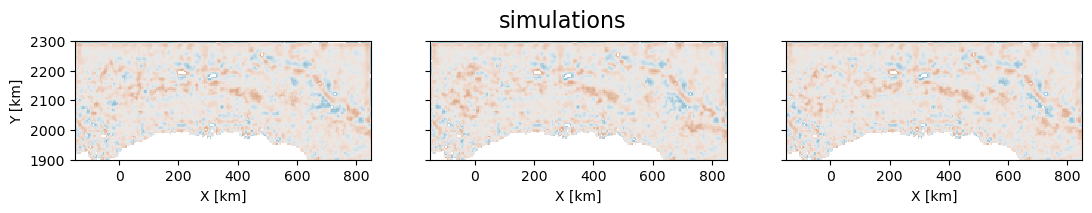

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(13,2), sharey=True)

sims = [sim1, sim2, sim3]
for sim, ax in zip(sims, axs):
    ax.pcolormesh(ds.x/1000, ds.y/1000, sim, cmap=cm.vik, vmin=-100, vmax=100)
    ax.axis('scaled')

axs[0].set_ylabel('Y [km]')
axs[0].set_xlabel('X [km]')
axs[1].set_xlabel('X [km]')
axs[2].set_xlabel('X [km]')

plt.suptitle('simulations', fontsize=16, y=0.95)

plt.show()

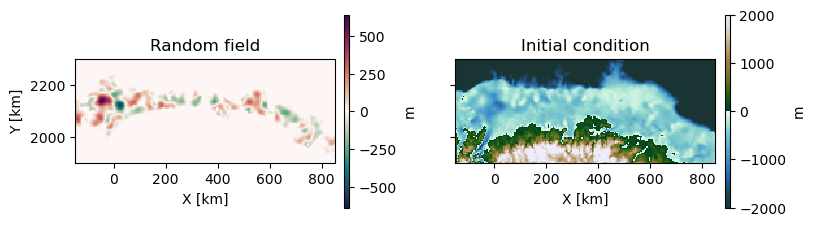

In [26]:
xkm = xx/1000
ykm = yy/1000

# make arrays for random field generation
range_max = [50e3, 50e3]
range_min = [30e3, 30e3]
high_step = 300
nug_max = 0.0
eps = 3e-4

rfgen = RFGen(ds, range_max, range_min, high_step, nug_max, eps, 'Gaussian', const_var=True, rng=rng)
field = rfgen.generate_field(condition=True)

x0 = ds.bed.values + field
x0 = np.where(x0>ds.surface-ds.thickness, ds.surface-ds.thickness, x0)

vmax = np.max(np.abs(field))

fig, axs = plt.subplots(1, 2, figsize=(9,2.5), sharey=True)
ax = axs[0]
im = ax.pcolormesh(xkm, ykm, field, vmax=vmax, vmin=-vmax, cmap='cmo.curl')
ax.axis('scaled')
ax.set_title('Random field')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.colorbar(im, ax=ax, label='m', pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(xkm, ykm, x0, vmax=2000, vmin=-2000, cmap=cm.bukavu)
ax.axis('scaled')
ax.set_title('Initial condition')
ax.set_xlabel('X [km]')
plt.colorbar(im, ax=ax, label='m', pad=0.03, aspect=40)

plt.show()

In [27]:
density_dict = {
    'ice' : 917,
    'water' : 1027,
    'rock' : 2670
}

grav_mskd = grav[grav.inv_pad==True]
pred_coords = (grav_mskd.x.values, grav_mskd.y.values, grav_mskd.height.values)

pred_coords[0].shape

(5636,)

In [28]:
vario

{'azimuth': 0,
 'nugget': 0,
 'major_range': np.float64(22201.87197564639),
 'minor_range': np.float64(22201.87197564639),
 'sill': np.float64(1.0423075776398305),
 'vtype': 'matern',
 's': np.float64(3.5560757736127395)}

In [29]:
sim = np.where(ds.inv_msk==False, residual_grid, sim)
target = grav.faa - (sim + trend)[grav_mask]

boug_filt = filter_boug(ds, grav, target, cutoff=20e3, pad=0)
target_filt = grav.faa.values - boug_filt
target_filt = target_filt[grav.inv_pad==True]

target = target[grav.inv_pad==True]
target_grid, target_filt_grid = xy_into_grid(ds.x.values, ds.y.values, (grav_mskd.x.values, grav_mskd.y.values), (target, target_filt))

grav_mskd = grav[grav.inv_pad==True]

target.shape, grav_mskd.shape

((5636,), (5636, 7))

In [30]:
np.count_nonzero(np.isnan(target))

0

In [31]:
np.count_nonzero(np.isnan(sim))

1853

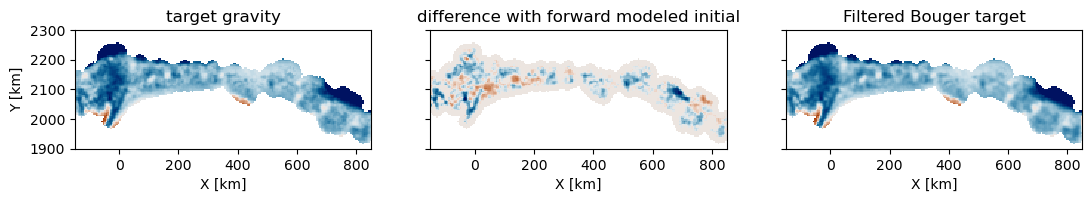

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(13,2), sharey=True)
ax = axs[0]
ax.pcolormesh(xkm, ykm, target_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('target gravity')

ax = axs[1]
ax.pcolormesh(xkm, ykm, target_grid-g_z_grid, vmin=-50, vmax=50, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('difference with forward modeled initial')

ax = axs[2]
ax.pcolormesh(xkm, ykm, target_filt_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Filtered Bouger target')

plt.show()

In [33]:
density_dict = {
    'ice' : 917,
    'water' : 1027,
    'rock' : 2670
}

pred_coords = (grav_mskd.x.values, grav_mskd.y.values, grav_mskd.height.values)

pred_coords[0].shape, target.shape

((5636,), (5636,))

In [34]:
# # block size, range, amplitude, iterations
# sequence = [
#     [21, 10, 60, 1000],
#     [15, 8, 40, 1000],
#     [9, 6, 40, 5000],
#     [5, 5, 40, 10000]
# ]

# # gravity uncertainty
# sigma = 1.6

sequence = [
    [21, 10, 60, 1000],
    [15, 8, 80, 1000],
    [9, 6, 100, 5000],
    [5, 5, 100, 10000]
]

# gravity uncertainty
sigma = ds.stdev.values[grav_mask][grav.inv_pad==True]

# RMSE stopping condition
stop = 3.5

# run chain sequence and time it
tic = time.time()
result = chain_sequence(sequence, ds, x0, pred_coords, target, sigma, density_dict, rng, stop=stop)
toc = time.time()
print(f'total time: {toc-tic:.1f}')

  0%|          | 0/1000 [00:00<?, ?it/s]

chain 0 efficiency: -0.028 RMSE/sec


  0%|          | 0/1000 [00:00<?, ?it/s]

chain 1 efficiency: -0.007 RMSE/sec


  0%|          | 0/5000 [00:00<?, ?it/s]

chain 2 efficiency: -0.004 RMSE/sec


  0%|          | 0/10000 [00:00<?, ?it/s]

chain 3 efficiency: -0.000 RMSE/sec
0 finished
total time: 90.6


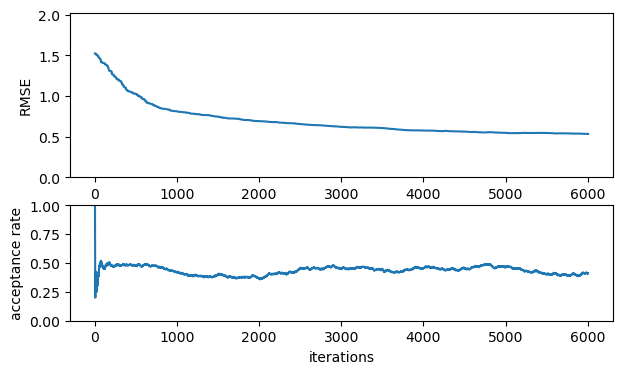

In [35]:
rmse = np.sqrt(result['loss_cache']/target.size)

fig, axs = plt.subplots(2, 1, figsize=(7,4), gridspec_kw=dict(height_ratios=[1,0.7]))
ax = axs[0]
ax.plot(rmse)
ax.set_ylim(0, np.max(rmse)+0.5)
ax.set_ylabel('RMSE')

# running acceptance rate with a 500 iteration window
run_acc = run_acceptance_rate(result['step_cache'], 500, 0)

ax = axs[1]
ax.plot(run_acc)
ax.set_xlabel('iterations')
ax.set_ylabel('acceptance rate')
ax.set_ylim(0, 1)
plt.show()

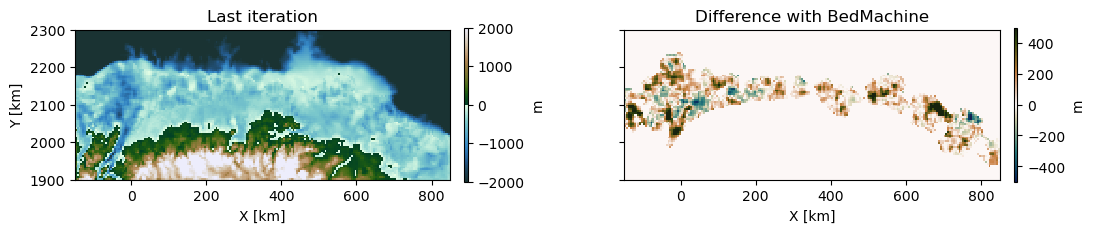

In [36]:
bed = result['bed_cache']

topo_cmap = get_topo_cm()
topo_crop = cmocean.tools.crop(cm.bukavu, np.min(bed), np.max(bed), 0)
vmin_topo = np.min(bed); vmax_topo = np.max(bed)

fig, axs = plt.subplots(1, 2, figsize=(13,2), sharey=True)

# plot last bed iteration
ax = axs[0]
im = ax.pcolormesh(xkm, ykm, bed, vmin=-2000, vmax=2000, cmap=cm.bukavu)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Last iteration')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')

# plot difference from BedMachine
ax = axs[1]
im = ax.pcolormesh(xkm, ykm, ds.bed-bed, vmin=-500, vmax=500, cmap='cmo.tarn_r')
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Difference with BedMachine')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')
plt.show()

In [37]:
target_grid, grav_result_grid = xy_into_grid(ds.x.values, ds.y.values, (pred_coords[0], pred_coords[1]), 
                                             (target, result['grav_cache']))

grav_residual_grid = target_grid - grav_result_grid

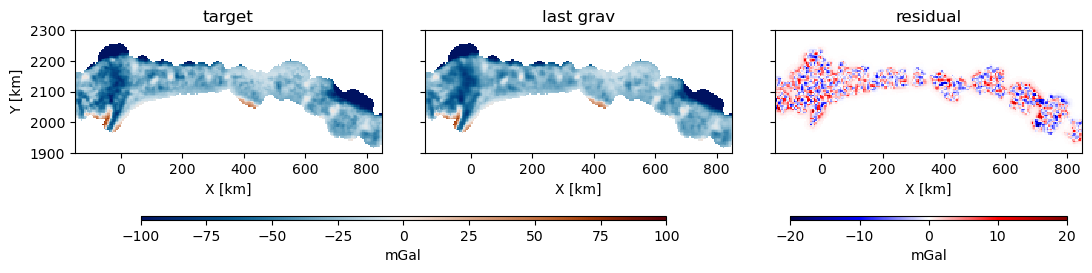

In [38]:
#fig, axs = plt.subplots(1, 3, figsize=(15,5), sharey=True)

fig = plt.figure(figsize=(13,3))
gridspec = GridSpec(2, 3, height_ratios=[1, 0.02], wspace=0.14)

ax1 = fig.add_subplot(gridspec[0,0])
ax2 = fig.add_subplot(gridspec[0,1])
ax3 = fig.add_subplot(gridspec[0,2])

ax = ax1
im = ax.pcolormesh(xkm, ykm, target_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('target')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')

ax = ax2
im = ax.pcolormesh(xkm, ykm, grav_result_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('last grav')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs2 = GridSpecFromSubplotSpec(1, 100, gridspec[1,:2])
cax = fig.add_subplot(gs2[10:90])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')

ax = ax3
im = ax.pcolormesh(xkm, ykm, grav_residual_grid, vmin=-20, vmax=20, cmap='seismic')
ax.axis('scaled')
ax.set_title('residual')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs3 = GridSpecFromSubplotSpec(1, 100, gridspec[1,2])
cax = fig.add_subplot(gs3[5:95])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')
plt.show()

In [39]:
bed_filt = lowpass_filter_invpad(ds, bed, cutoff=10e3)
bed_filt = bed_filt.reshape(bed.shape)
bed_high = bed-bed_filt

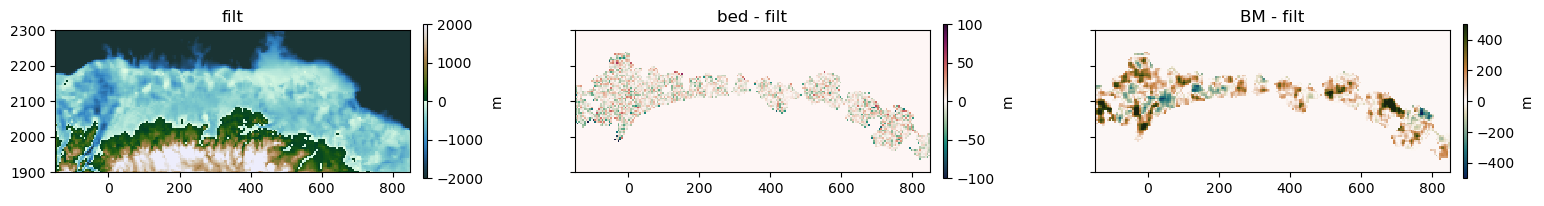

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(19,2), sharey=True)
ax = axs[0]
im = ax.pcolormesh(xkm, ykm, bed_filt, vmin=-2000, vmax=2000, cmap=cm.bukavu)
ax.axis('scaled')
ax.set_title('filt')
plt.colorbar(im, pad=0.03, aspect=40, ax=ax, label='m')

ax = axs[1]
im = ax.pcolormesh(xkm, ykm, bed-bed_filt, vmin=-100, vmax=100, cmap='cmo.curl')
ax.axis('scaled')
ax.set_title('bed - filt')
plt.colorbar(im, pad=0.03, aspect=40, ax=ax, label='m')

ax = axs[2]
im = ax.pcolormesh(xkm, ykm, ds.bed-bed_filt, vmin=-500, vmax=500, cmap='cmo.tarn_r')
ax.axis('scaled')
ax.set_title('BM - filt')
plt.colorbar(im, pad=0.03, aspect=40, ax=ax, label='m')
plt.show()

In [41]:
prisms, densities = make_prisms(ds, bed_filt, density_dict)
g_z = hm.prism_gravity(pred_coords, prisms, densities, field='g_z')

In [42]:
np.sqrt(np.mean(np.square(target-g_z)))

np.float64(3.391248468636466)

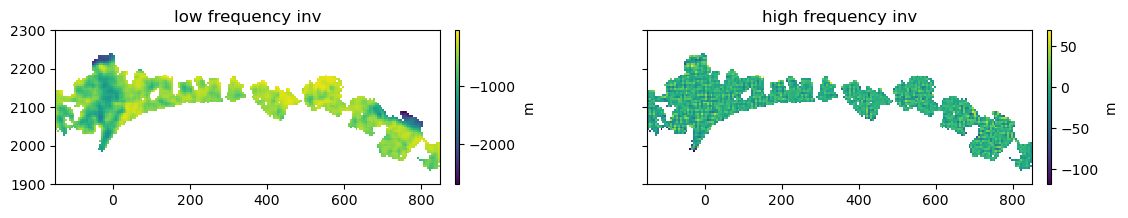

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(14,2), sharey=True)

ax = axs[0]
im = ax.pcolormesh(xkm, ykm, np.where(ds.inv_msk, bed_filt, np.nan))
ax.axis('scaled')
ax.set_title('low frequency inv')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')

ax = axs[1]
im = ax.pcolormesh(xkm, ykm, np.where(ds.inv_msk, bed_high, np.nan))
ax.axis('scaled')
ax.set_title('high frequency inv')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')
plt.show()

# Gauss-Newton method

In [44]:
bed_cache, rmse_cache = gauss_newton(ds, target_filt, pred_coords, density_dict, max_iter=30, alpha=0.5, perturb_scale=1, lamb=0.00, stop=0.001, quiet=False)

# start 	 RMSE: 7.933
# 1 	 RMSE: 4.088 	 time elapsed: 12.58 s
# 2 	 RMSE: 2.323 	 time elapsed: 17.95 s
# 3 	 RMSE: 1.598 	 time elapsed: 23.29 s
# 4 	 RMSE: 1.357 	 time elapsed: 29.21 s
# 5 	 RMSE: 1.290 	 time elapsed: 34.87 s
# 6 	 RMSE: 1.274 	 time elapsed: 40.53 s
# 7 	 RMSE: 1.271 	 time elapsed: 47.13 s
# 8 	 RMSE: 1.271 	 time elapsed: 53.17 s
# 9 	 RMSE: 1.271 	 time elapsed: 85.10 s
reached stopping criterion after 9 iterations


In [45]:
ds.bed.values[ds.inv_msk.values==True].size, grav_mskd.shape[0]

(3305, 5636)

In [46]:
bed_cache.shape

(10, 80, 200)

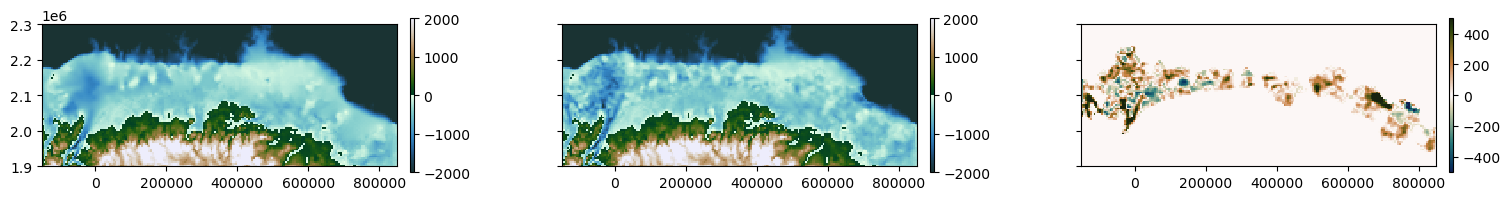

In [47]:
index = -1

fig, axs = plt.subplots(1, 3, figsize=(19,2), sharey=True)

ax = axs[0]
im = ax.pcolormesh(ds.x, ds.y, ds.bed, cmap=cm.bukavu, vmin=-2000, vmax=2000)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x, ds.y, bed_cache[index,...], cmap=cm.bukavu, vmin=-2000, vmax=2000)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ds.x, ds.y, ds.bed-bed_cache[index,...], cmap='cmo.tarn_r', vmin=-500, vmax=500)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

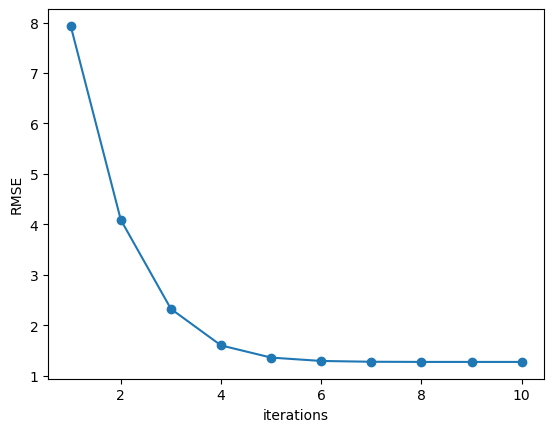

In [48]:
plt.plot(np.arange(1, rmse_cache.size+1), rmse_cache, 'o-')
plt.xlabel('iterations')
plt.ylabel('RMSE')
plt.show()

In [49]:
prisms, densities = make_prisms(ds, bed_cache[-1,...], density_dict)
g_z_new = hm.prism_gravity(pred_coords, prisms, densities, field='g_z')

target_grid, grav_result_grid = xy_into_grid(ds.x.values, ds.y.values, (pred_coords[0], pred_coords[1]), 
                                             (target_filt, g_z_new))

grav_residual_grid = target_grid - grav_result_grid

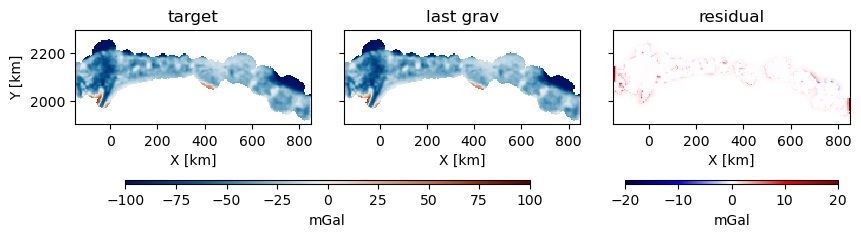

In [50]:
xkm = ds.x.values/1000
ykm = ds.y.values/1000

fig = plt.figure(figsize=(10,2.5))
gridspec = GridSpec(2, 3, height_ratios=[1, 0.02], wspace=0.14)

ax1 = fig.add_subplot(gridspec[0,0])
ax2 = fig.add_subplot(gridspec[0,1])
ax3 = fig.add_subplot(gridspec[0,2])

ax = ax1
im = ax.pcolormesh(xkm, ykm, target_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('target')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')

ax = ax2
im = ax.pcolormesh(xkm, ykm, grav_result_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('last grav')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs2 = GridSpecFromSubplotSpec(1, 100, gridspec[1,:2])
cax = fig.add_subplot(gs2[10:90])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')

ax = ax3
im = ax.pcolormesh(xkm, ykm, grav_residual_grid, vmin=-20, vmax=20, cmap='seismic')
ax.axis('scaled')
ax.set_title('residual')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs3 = GridSpecFromSubplotSpec(1, 100, gridspec[1,2])
cax = fig.add_subplot(gs3[5:95])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')
plt.show()

In [51]:
np.sqrt(np.mean(np.square(target_filt - g_z_new)))

np.float64(1.2706904316189356)

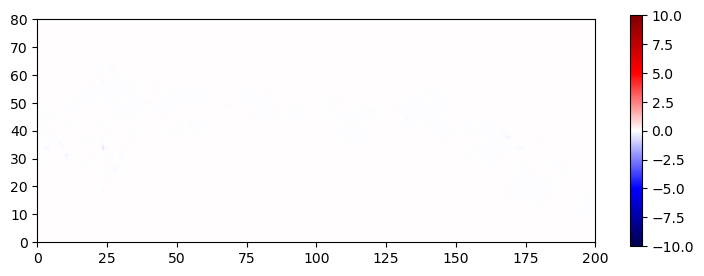

In [52]:
plt.figure(figsize=(9,3))
plt.pcolormesh(bed_cache[-1,...]-bed_cache[-2,...], vmin=-10, vmax=10, cmap='seismic')
plt.axis('scaled')
plt.colorbar()
plt.show()

In [53]:
lapop = make_laplace(ds.bed.values)
lapop_trim = trim_laplace(lapop, ds.inv_msk.values)

Wm = lapop_trim
Cm = Wm.T@Wm

stdev = ds.stdev.values[grav_mask & ds.inv_pad.values]
weights = 1/stdev**2

Wd = np.diag(weights)

prior = ds.bed.values.astype(np.float64)

In [55]:
lambdas = np.concatenate([[1e-3, 1e-4], np.logspace(-5, -9, num=10), [1e-10, 1e-11]])
data_fits = []
model_fits = []

lopt, data_fits, model_fits, dists = lcurve(lambdas, ds, prior, target, pred_coords, density_dict, Cm, Wd, max_iter=30, alpha=0.5, perturb_scale=1, stop=0.01, quiet=True)

  0%|          | 0/14 [00:00<?, ?it/s]

In [56]:
print(f'optimal lambda: {lopt:.2e}')

optimal lambda: 5.99e-08


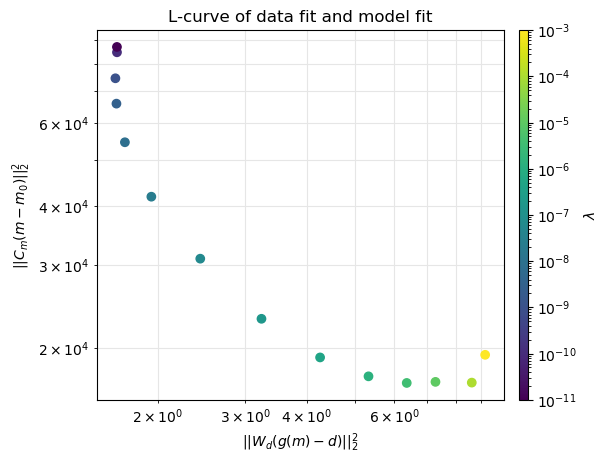

In [57]:
from matplotlib import colors

fig, ax = plt.subplots(1, 1)
im = ax.scatter(data_fits, model_fits, c=lambdas, norm=colors.LogNorm(), zorder=9999)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$||W_d(g(m)-d)||_{2}^{2}$')
ax.set_ylabel(r'$||C_m(m-m_0)||_{2}^{2}$')
ax.set_title('L-curve of data fit and model fit')
ax.grid()
ax.grid(which="minor", color="0.9")
plt.colorbar(im, pad=0.03, aspect=40, label=r'$\lambda$')
plt.show()

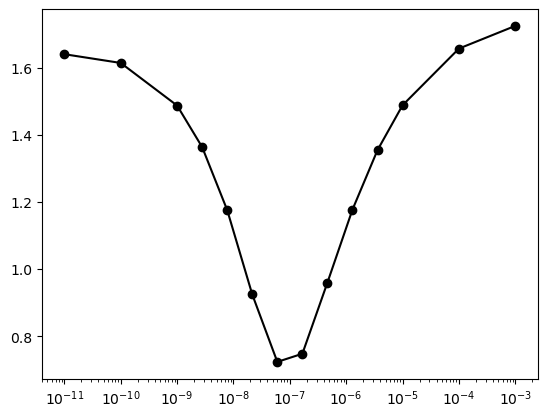

In [58]:
fig, ax = plt.subplots(1, 1)
ax.plot(lambdas, dists, 'ko-')
ax.set_xscale('log')
plt.show()

In [61]:
bed_cache, rmse_cache = gauss_newton_regularized(ds, prior, target, pred_coords, density_dict, Cm, Wd, max_iter=30, alpha='search', perturb_scale=1, lamb=lopt, stop=0.001, quiet=False)

# start 	 RMSE: 8.193
# 1 	 RMSE: 1.475 	 time elapsed: 15.75 s
# 2 	 RMSE: 1.419 	 time elapsed: 27.99 s
# 3 	 RMSE: 1.411 	 time elapsed: 40.27 s
# 4 	 RMSE: 1.409 	 time elapsed: 52.63 s
# 5 	 RMSE: 1.409 	 time elapsed: 61.75 s
# 6 	 RMSE: 1.409 	 time elapsed: 73.48 s
reached stopping criterion after 6 iterations


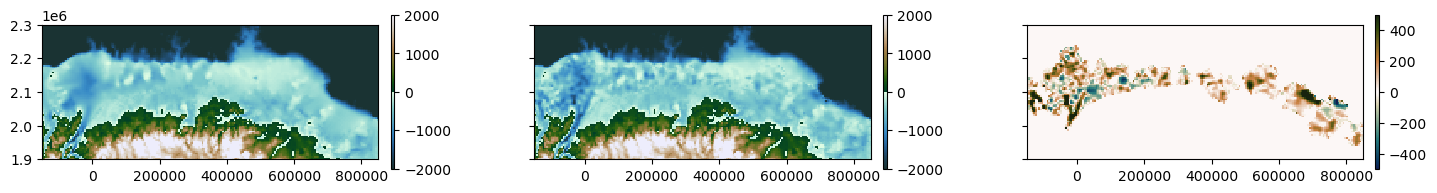

In [64]:
index = -1

fig, axs = plt.subplots(1, 3, figsize=(18,2), sharey=True)

ax = axs[0]
im = ax.pcolormesh(ds.x, ds.y, ds.bed, cmap=cm.bukavu, vmin=-2000, vmax=2000)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x, ds.y, bed_cache[index,...], cmap=cm.bukavu, vmin=-2000, vmax=2000)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ds.x, ds.y, ds.bed-bed_cache[index,...], cmap='cmo.tarn_r', vmin=-500, vmax=500)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

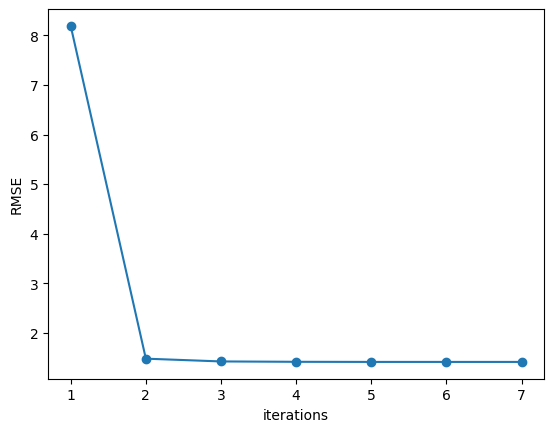

In [65]:
plt.plot(np.arange(1, rmse_cache.size+1), rmse_cache, 'o-')
plt.xlabel('iterations')
plt.ylabel('RMSE')
plt.show()

In [66]:
prisms, densities = make_prisms(ds, bed_cache[-1,...], density_dict)
g_z_new = hm.prism_gravity(pred_coords, prisms, densities, field='g_z')

target_grid, grav_result_grid = xy_into_grid(ds.x.values, ds.y.values, (pred_coords[0], pred_coords[1]), 
                                             (target, g_z_new))

grav_residual_grid = target_grid - grav_result_grid

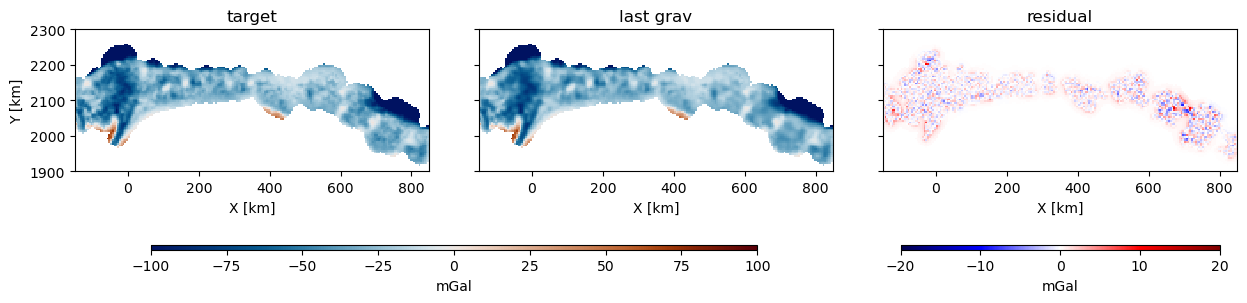

In [68]:
xkm = ds.x.values/1000
ykm = ds.y.values/1000

fig = plt.figure(figsize=(15,3.5))
gridspec = GridSpec(2, 3, height_ratios=[1, 0.02], wspace=0.14)

ax1 = fig.add_subplot(gridspec[0,0])
ax2 = fig.add_subplot(gridspec[0,1])
ax3 = fig.add_subplot(gridspec[0,2])

ax = ax1
im = ax.pcolormesh(xkm, ykm, target_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('target')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')

ax = ax2
im = ax.pcolormesh(xkm, ykm, grav_result_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('last grav')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs2 = GridSpecFromSubplotSpec(1, 100, gridspec[1,:2])
cax = fig.add_subplot(gs2[10:90])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')

ax = ax3
im = ax.pcolormesh(xkm, ykm, grav_residual_grid, vmin=-20, vmax=20, cmap='seismic')
ax.axis('scaled')
ax.set_title('residual')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs3 = GridSpecFromSubplotSpec(1, 100, gridspec[1,2])
cax = fig.add_subplot(gs3[5:95])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')
plt.show()